# Time-Series Prediction with Quantum Reservoir Computing
This tutorial gives an introduction to Quantum Reservoir Computing (QRC) for time-series prediction.

QRC is a Quantum Machine Learning (QML) approach for time-series prediction and classification. The reservoir is a fixed, nonlinear quantum system: when it is fed with an input signal, its natural dynamics map the signal into a high-dimensional space of quantum states. Only a simple linear readout on top of the reservoir is trained.

The approach was introduced by [Fujii & Nakajima](https://journals.aps.org/prapplied/abstract/10.1103/PhysRevApplied.8.024030), who established QRC as a QML strategy suited to NISQ devices. QRC is closely related to Quantum Extreme Learning Machines (QELM); here we focus on the original setup of Fujii & Nakajima. For a broader overview, see [this review](https://link.springer.com/chapter/10.1007/978-981-13-1687-6_18).

As a benchmark we use the Nonlinear AutoRegressive Moving Average ([NARMA](https://ieeexplore.ieee.org/document/846741)) time series, a synthetic nonlinear dynamical system that is a standard test for reservoir computers.

## Theoretical Overview

We consider a time-series task where we learn to predict a target series $\{y_k\}_{k=1}^L$ from an input series $\{s_k\}_{k=1}^L$. The prediction $\hat{y}_k$ may depend on all inputs up to time $k$, i.e. $\hat{y}_k = f(s_1, \ldots, s_k)$.

The reservoir is an $N$-qubit system evolving under the Hamiltonian of a fully connected transverse-field Ising model:

$$ H=\sum_{i<j} J_{ij} X_i X_j + h\sum_{i} Z_i $$

The couplings $J_{ij}$ are drawn uniformly from $[-J/2, J/2]$ and stay fixed. At every time step $k$ the input is injected by replacing the first qubit with the state

$$\ket{\psi_{s_k}} = \sqrt{1 - s_k}\,\ket{0} + \sqrt{s_k}\,\ket{1},\qquad \rho \;\longmapsto\; \ket{\psi_{s_k}}\!\bra{\psi_{s_k}} \otimes \operatorname{Tr}_{1}\!\left[\rho\right],$$

after which the whole register evolves for a time $\tau$ under $U = e^{-iH\tau}$. In the circuit below, $U$ is approximated by a Trotter decomposition.

After each step (and at each virtual node) we read out the single- and two-qubit expectation values $x_{k} = \left(\langle Z_i \rangle_k,\ \langle Z_i Z_j \rangle_k\right)$. These features are combined by a linear readout, which is the only part that is trained:

$$\hat{y}_k = \sum_{i} w_{i}\, x_{k,i} + w_0$$

A simple improvement to the performance of a QRC system is [temporal](https://journals.aps.org/prapplied/abstract/10.1103/PhysRevApplied.8.024030) and [spatial multiplexing](https://journals.aps.org/prapplied/abstract/10.1103/PhysRevApplied.11.034021). Temporal multiplexing splits the evoluation $\tau$ into $V$ substeps of $\tau/V$, referenced as _virtual nodes_. Observables are read out after each one, so instead of $n\_features$ we get $V * n\_features$ in total. Spatial multiplexing introduces the use of several distinct QRC systems, all driven by the same input signal. In this tutorial we will only introduce time multiplexing. 

**Note on the simulation:** In the original proposal a single reservoir runs continuously through the whole time series, and the observables are read out after every step. In simulation this is impractical: every readout would have to re-simulate the full history, so the cost grows quadratically with the length of the series. Instead, we exploit that the reservoir has *fading memory*: inputs far in the past have almost no influence on the current state. For every time step $k$ we therefore start from $\ket{0\ldots0}$ and only replay the last `window` inputs $s_{k-\text{window}+1}, \ldots, s_k$. This gives approximately the same features at a cost that is linear in the length of the series. The swapped-out input qubits are simply never measured, which realizes the partial trace $\operatorname{Tr}_1$ above. For the `virtual_nodes`, a measurement destroys the state, so every one needs its own circuit, increasing runtime.

### Preliminaries

Install sklearn, which is needed for the linear layer.

`pip install scikit-learn`

### NARMA time series

The NARMA task of order $n$ is defined by the recursion

$$y_{k} = 0.3,y_{k-1} + 0.05,y_{k-1}\sum_{i=1}^{n} y_{k-i} + 1.5,s_{k-n+1},s_{k} + 0.1$$

with inputs $s_k$ drawn uniformly from $[0, 0.5]$. To predict $y_k$ well, a model has to remember the inputs of the last $n$ steps and combine them nonlinearly, so the order $n$ controls how difficult the task is.

In [21]:
import numpy as np
import matplotlib.pyplot as plt


def create_NARMA(n_samples=1000, order=10, seed=0):
    """
    Create a NARMA (Nonlinear AutoRegressive Moving Average) dataset.

    Args:
        n_samples (int): Length of the time series.
        order (int): Order of the NARMA system.
        seed (int): Seed for the random input series.

    Returns:
        s (numpy.ndarray): Input series of shape (n_samples,).
        y (numpy.ndarray): Target values of shape (n_samples,).
    """
    rng = np.random.default_rng(seed)

    # Random inputs in [0, 0.5] keep the NARMA recursion bounded
    s = rng.uniform(0, 0.5, n_samples)
    y = np.zeros(n_samples)

    for k in range(order, n_samples):
        y[k] = (
            0.3 * y[k - 1]
            + 0.05 * y[k - 1] * np.sum(y[k - order:k])
            + 1.5 * s[k - order + 1] * s[k]
            + 0.1
        )

    return s, y


def visualize_NARMA(y, predictions=None, title="NARMA time series"):
    """
    Plot the NARMA target series and, optionally, predictions.

    Args:
        y (numpy.ndarray): Target values.
        predictions (numpy.ndarray, optional): Predicted values aligned with ``y``.
        title (str): Title of the plot.
    """
    plt.figure(figsize=(12, 4))
    plt.plot(y, label="Target", color="#20306f")

    if predictions is not None:
        plt.plot(predictions, label="Prediction", color="#6929C4", linestyle="--")

    plt.title(title)
    plt.xlabel("Time step")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.show()

### Quantum Reservoir

The `QuantumReservoir` class builds the Hamiltonian with Qrisp's operator module and obtains the (Trotterized) time evolution via `trotterization()`. For each time step, `process` prepares a fresh register, feeds in the last `window` inputs and evolves the register after each injection. `_get_observables` then turns the measurement distribution of each register into the feature vector $x_k$.

In [50]:
from qrisp import QuantumVariable, ry, swap
from qrisp.operators import X as PauliX, Z as PauliZ


class QuantumReservoir:
    """A quantum reservoir following Fujii & Nakajima (Phys. Rev. Applied 8, 024030).

    Qubit 0 is the input qubit, the other qubits are memory. Each time step the input qubit
    is replaced by sqrt(1-u)|0> + sqrt(u)|1> and the whole register evolves for tau under
        H = sum_{i<j} J_ij X_i X_j + h sum_i Z_i,    J_ij ~ U(-j_scale/2, j_scale/2).
    Memory is carried quantumly and fades, so each feature row replays only the last
    `window` inputs from |0...0>.
    """

    def __init__(self, qubits: int = 4, seed: int = 0, tau: float = 1.0, h_field: float = 1.0,
                 j_scale: float = 1.0, trotter_steps: int = 2, input_window: int = 4, virtual_nodes: int = 1):
        self.qubits = qubits # number of qubits in the reservoir
        self.tau = tau # total evolution time for each input
        self.trotter_steps = trotter_steps # number of Trotter steps for the evolution
        self.input_window = input_window # number of previous inputs to consider for each feature row
        self.virtual_nodes = virtual_nodes # number of virtual nodes for each input (subdivides tau into V sub-steps)
        rng = np.random.default_rng(seed)
        H = h_field * sum(PauliZ(i) for i in range(qubits))
        for i in range(qubits):
            for j in range(i + 1, qubits):
                H += rng.uniform(-j_scale / 2, j_scale / 2) * PauliX(i) * PauliX(j)
        self.H = H
        self.U = H.trotterization()

    def process(self, series, show_circuit=False):
        """Row k holds the observables at times tau/V, 2tau/V, ..., tau after injecting input k."""
        V = self.virtual_nodes
        dt = self.tau / V
        steps = max(1, self.trotter_steps // V)  # Trotter steps per sub-step
        rows = []
        for k in range(len(series)):
            inputs = series[max(0, k - self.input_window + 1):k + 1]
            row = []
            for v in range(1, V + 1):
                variable = QuantumVariable(self.qubits)
                for idx, u in enumerate(inputs):
                    fresh = QuantumVariable(1)
                    ry(2 * np.arcsin(np.sqrt(u)), fresh[0])
                    swap(fresh[0], variable[0])
                    n_sub = v if idx == len(inputs) - 1 else V
                    for _ in range(n_sub):
                        self.U(variable, t=dt, steps=steps)
                row.append(variable)
            rows.append(row)
        # one feature block per virtual node, side by side
        return np.hstack([self._get_observables([row[v] for row in rows]) for v in range(V)])

    def _get_observables(self, variables):
        """Compute <Z_i> and <Z_i Z_j> for each QuantumVariable from its measurement distribution."""
        n = self.qubits
        pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
        features = []
        for qv in variables:
            z, zz = np.zeros(n), np.zeros(len(pairs))
            for bits, p in qv.get_measurement().items():
                signs = np.array([1 - 2 * int(b) for b in bits])   # bit 0 -> +1, bit 1 -> -1
                z += p * signs # compute <Z_i>
                zz += p * np.array([signs[i] * signs[j] for i, j in pairs]) # compute <Z_i Z_j>
            features.append(np.concatenate([z, zz]))
        return np.array(features)  # (n_samples, n_features)

## Predicting NARMA-2

We generate a NARMA series of order 2 and set up the reservoir. The replay `window` must cover at least the order of the task, since the reservoir can't remember inputs it never saw. For order 5, each value $y_k$ depends directly on the previous two outputs $y_{k-1}, y_{k-2}$ and the previous two inputs $s_{k-1}, s_{k-2}$. 

_Note_: NARMA-2 is a fairly easy task. Higher orders such as NARMA-10 need a larger reservoir, which is too expensive to simulate in this tutorial. If you're curious and ready to wait, set `NARMA_ORDER` higher and increase `window` (to at least the NARMA order), `qubits` and `virtual_nodes`. Be aware that the simulation cost grows exponentially with `qubits + window`.

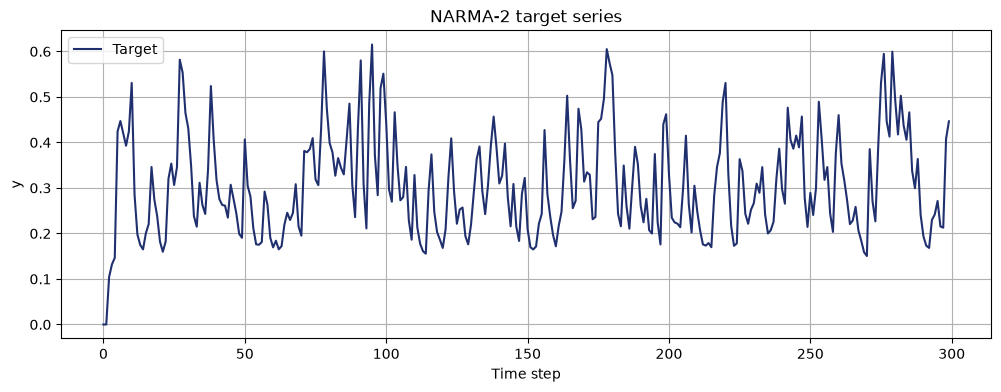

In [54]:
N_SAMPLES = 300 # Sample size for the NARMA dataset
NARMA_ORDER = 2 # Order of the NARMA system 

s, y = create_NARMA(N_SAMPLES, order=NARMA_ORDER, seed=0)
visualize_NARMA(y, title=f"NARMA-{NARMA_ORDER} target series")

In [57]:
RESERVOIR_CONFIG = {
    "qubits": 6,
    "seed": 0,
    "tau": 1.0,
    "h_field": 1.0,
    "j_scale": 1.0,
    "trotter_steps": 2,
    "input_window": 2,
    "virtual_nodes": 4
}

reservoir = QuantumReservoir(**RESERVOIR_CONFIG)
features = reservoir.process(s)
print(f"Feature matrix shape: {features.shape}") # Each virtual node contributes n_features, so the total number of features is virtual_nodes * n_features.

Feature matrix shape: (300, 84)                                                 


### Training the readout

The data is split chronologically into a training and a test part. We fit a ridge regression, choosing its regularization strength by cross-validation, and report the coefficient of determination $R^2$ on the test data ($R^2 = 1$ is a perfect prediction, $R^2 = 0$ is no better than predicting the mean).

QRC test R^2: 0.906


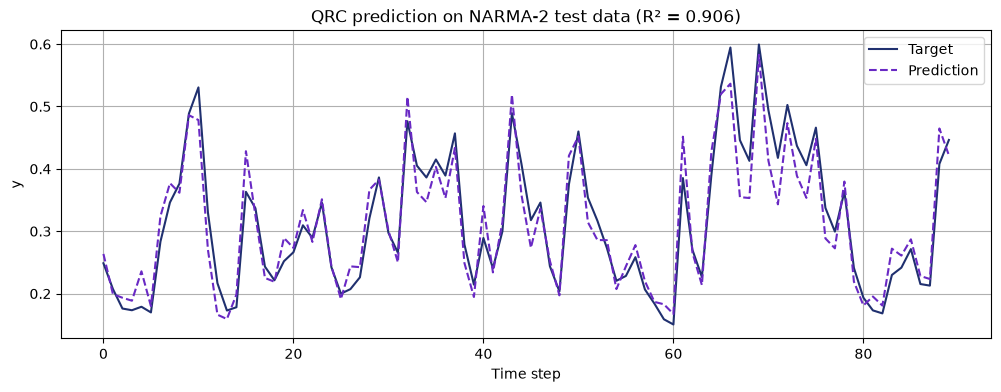

In [58]:
from sklearn.linear_model import RidgeCV

TRAIN_FRAC = 0.7  # the remaining 30% are used for testing

split = int(TRAIN_FRAC * N_SAMPLES)

RIDGE_ALPHAS = np.logspace(-8, 4, 13)

def fit_and_score(feats):
    readout = RidgeCV(alphas=RIDGE_ALPHAS).fit(feats[0:split], y[0:split])
    return readout, readout.score(feats[split:], y[split:])

readout, score = fit_and_score(features)
print(f"QRC test R^2: {score:.3f}")

visualize_NARMA(y[split:], predictions=readout.predict(features[split:]),
                title=f"QRC prediction on NARMA-{NARMA_ORDER} test data (R² = {score:.3f})")

## Summary

In this tutorial we

- built a quantum reservoir from a transverse-field Ising Hamiltonian using Qrisp's operator module
- injected a time series by swapping in freshly prepared input qubits, exploiting fading memory
- trained a linear readout on the reservoir's $\langle Z_i\rangle$ and $\langle Z_iZ_j\rangle$ expectation values
- achieved good performance on the NARMA-2 benchmark, which is fundamental when working with QRC systems

If you're curious, natural next steps could be to tune the evolution time `tau`, the field strength `h_field` and the number of qubits or to try other benchmarks such as the Mackey-Glass series. 